# 01 - Vanilla CNN (from scratch)

Trains **Vanilla CNN (from scratch)** on cached fundus crops with the frozen 5-fold splits; reports per-bigclass one-vs-rest AUC (Fig 2a style), macro AUC and frequency-weighted F1. All logic lives in `fundus_lib`.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, glob
# auto-locate the folder that actually contains fundus_lib
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
print("PROJECT_DIR ->", PROJECT_DIR)

DATA_ROOT   = os.path.join(PROJECT_DIR, "1000images")
CACHE_DIR   = os.path.join(PROJECT_DIR, "cache_crops")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")
MANIFEST    = os.path.join(PROJECT_DIR, "manifest_cached.json")
SPLITS      = os.path.join(PROJECT_DIR, "splits.json")
os.makedirs(RESULTS_DIR, exist_ok=True)

%pip install -q timm transformers torchinfo grad-cam

sys.path.insert(0, PROJECT_DIR)
import fundus_lib as fl
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| imported fundus_lib OK")

Mounted at /content/drive
PROJECT_DIR -> /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 72.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda | imported fundus_lib OK


## Load frozen manifest + splits

In [2]:
import json, numpy as np
manifest = json.load(open(MANIFEST))
splits   = fl.data.load_splits(SPLITS)
folds    = np.array(splits["fold_of_index"])
MODEL_NAME = "cnn"
EPOCHS = 100
BATCH = 16
c2i, i2c = fl.data.class_index_maps(range(10))
NUM_CLASSES = len(c2i)
train_tf, eval_tf = fl.models.get_transforms(MODEL_NAME)
print("model:", MODEL_NAME, "| classes:", NUM_CLASSES)

model: cnn | classes: 10


## 5-fold cross-validation

In [3]:
from torch.utils.data import DataLoader
fold_metrics, all_true, all_prob, histories = [], [], [], []
for test_fold in range(splits["n_splits"]):
    tr_idx, va_idx, te_idx = fl.data.fold_indices(folds, test_fold)
    ds_tr = fl.data.FundusDataset(manifest, tr_idx, train_tf, c2i)
    ds_va = fl.data.FundusDataset(manifest, va_idx, eval_tf, c2i)
    ds_te = fl.data.FundusDataset(manifest, te_idx, eval_tf, c2i)
    dl_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True, num_workers=2)
    dl_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False, num_workers=2)
    dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
    tr_labels = [c2i[manifest[i]["bigclass"]] for i in tr_idx]
    cw = fl.engine.class_weights_from_labels(tr_labels, NUM_CLASSES, device)
    if MODEL_NAME == "retfound":
        ckpt = RETFOUND_CKPT if os.path.exists(RETFOUND_CKPT) else None
        model = fl.models.build_model(MODEL_NAME, NUM_CLASSES, retfound_ckpt=ckpt)
    else:
        model = fl.models.build_model(MODEL_NAME, NUM_CLASSES)
    print(f"\n=== fold {test_fold} | train {len(tr_idx)} val {len(va_idx)} test {len(te_idx)} ===")
    model, hist = fl.engine.fit(model, dl_tr, dl_va, device, NUM_CLASSES,
                                epochs=EPOCHS, class_weights=cw, verbose=True)
    yt, yp = fl.engine.evaluate(model, dl_te, device)
    m = fl.metrics.compute_metrics(yt, yp, index_to_class=i2c)
    print("  fold %d: wF1=%.3f macroAUC=%.3f wAUC=%.3f" % (test_fold, m["weighted_f1"], m["macro_auc"], m["weighted_auc"]))
    fold_metrics.append(m); all_true.append(yt); all_prob.append(yp); histories.append(hist)



=== fold 0 | train 330 val 110 test 111 ===


/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.1830 val_loss 2.3436 | train_acc 0.179 val_acc 0.118 | val_wF1 0.0626
  epoch  1 | train_loss 1.8849 val_loss 1.8187 | train_acc 0.361 val_acc 0.355 | val_wF1 0.3750
  epoch  2 | train_loss 1.7988 val_loss 1.7825 | train_acc 0.403 val_acc 0.436 | val_wF1 0.4100
  epoch  3 | train_loss 1.7103 val_loss 1.5663 | train_acc 0.418 val_acc 0.473 | val_wF1 0.4593
  epoch  4 | train_loss 1.6445 val_loss 1.7259 | train_acc 0.436 val_acc 0.491 | val_wF1 0.4913
  epoch  5 | train_loss 1.5815 val_loss 1.4631 | train_acc 0.436 val_acc 0.564 | val_wF1 0.5547
  epoch  6 | train_loss 1.5835 val_loss 1.6490 | train_acc 0.479 val_acc 0.473 | val_wF1 0.4670
  epoch  7 | train_loss 1.5682 val_loss 1.5921 | train_acc 0.470 val_acc 0.491 | val_wF1 0.4899
  epoch  8 | train_loss 1.5901 val_loss 1.5723 | train_acc 0.445 val_acc 0.536 | val_wF1 0.5329
  epoch  9 | train_loss 1.6051 val_loss 1.5400 | train_acc 0.424 val_acc 0.527 | val_wF1 0.5123
  epoch 10 | train_loss 1.5503 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.1315 val_loss 2.4939 | train_acc 0.266 val_acc 0.109 | val_wF1 0.0371
  epoch  1 | train_loss 1.8901 val_loss 1.9125 | train_acc 0.366 val_acc 0.327 | val_wF1 0.2972
  epoch  2 | train_loss 1.7643 val_loss 1.8014 | train_acc 0.384 val_acc 0.400 | val_wF1 0.3963
  epoch  3 | train_loss 1.7449 val_loss 1.8613 | train_acc 0.438 val_acc 0.418 | val_wF1 0.4066
  epoch  4 | train_loss 1.7849 val_loss 1.7540 | train_acc 0.405 val_acc 0.464 | val_wF1 0.3984
  epoch  5 | train_loss 1.6427 val_loss 1.8745 | train_acc 0.441 val_acc 0.418 | val_wF1 0.4183
  epoch  6 | train_loss 1.6605 val_loss 1.7473 | train_acc 0.477 val_acc 0.391 | val_wF1 0.3842
  epoch  7 | train_loss 1.6017 val_loss 1.7081 | train_acc 0.426 val_acc 0.391 | val_wF1 0.3964
  epoch  8 | train_loss 1.6567 val_loss 1.6208 | train_acc 0.420 val_acc 0.500 | val_wF1 0.4800
  epoch  9 | train_loss 1.6164 val_loss 1.6519 | train_acc 0.468 val_acc 0.482 | val_wF1 0.4885
  epoch 10 | train_loss 1.5830 val_loss 

...

  epoch  0 | train_loss 2.1572 val_loss 2.4062 | train_acc 0.296 val_acc 0.100 | val_wF1 0.0212
  epoch  1 | train_loss 1.7953 val_loss 1.8163 | train_acc 0.360 val_acc 0.355 | val_wF1 0.3684
  epoch  2 | train_loss 1.7889 val_loss 1.6222 | train_acc 0.411 val_acc 0.391 | val_wF1 0.3637
  epoch  3 | train_loss 1.7096 val_loss 1.6411 | train_acc 0.453 val_acc 0.491 | val_wF1 0.4660
  epoch  4 | train_loss 1.7518 val_loss 1.5433 | train_acc 0.378 val_acc 0.464 | val_wF1 0.4598
  epoch  5 | train_loss 1.6972 val_loss 1.6873 | train_acc 0.441 val_acc 0.455 | val_wF1 0.4604
  epoch  6 | train_loss 1.7232 val_loss 1.5016 | train_acc 0.429 val_acc 0.518 | val_wF1 0.5083
  epoch  7 | train_loss 1.6332 val_loss 1.5493 | train_acc 0.453 val_acc 0.500 | val_wF1 0.4941
  epoch  8 | train_loss 1.6388 val_loss 1.4869 | train_acc 0.453 val_acc 0.473 | val_wF1 0.4746
  epoch  9 | train_loss 1.5870 val_loss 1.4277 | train_acc 0.468 val_acc 0.527 | val_wF1 0.5431
  epoch 10 | train_loss 1.5509 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.0847 val_loss 2.3105 | train_acc 0.266 val_acc 0.136 | val_wF1 0.0582
  epoch  1 | train_loss 1.8416 val_loss 1.8828 | train_acc 0.450 val_acc 0.345 | val_wF1 0.2981
  epoch  2 | train_loss 1.6767 val_loss 1.8390 | train_acc 0.438 val_acc 0.482 | val_wF1 0.4437
  epoch  3 | train_loss 1.7339 val_loss 1.9054 | train_acc 0.429 val_acc 0.436 | val_wF1 0.4128
  epoch  4 | train_loss 1.6910 val_loss 1.8380 | train_acc 0.438 val_acc 0.445 | val_wF1 0.4175
  epoch  5 | train_loss 1.6223 val_loss 1.8025 | train_acc 0.450 val_acc 0.418 | val_wF1 0.3980
  epoch  6 | train_loss 1.6620 val_loss 1.7581 | train_acc 0.483 val_acc 0.436 | val_wF1 0.4333
  epoch  7 | train_loss 1.6186 val_loss 1.7998 | train_acc 0.486 val_acc 0.464 | val_wF1 0.4462
  epoch  8 | train_loss 1.5761 val_loss 1.8938 | train_acc 0.489 val_acc 0.400 | val_wF1 0.3617
  epoch  9 | train_loss 1.4588 val_loss 1.7346 | train_acc 0.505 val_acc 0.418 | val_wF1 0.4174
  epoch 10 | train_loss 1.4963 val_loss 

/content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/engine.py:88: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None


  epoch  0 | train_loss 2.0214 val_loss 2.5279 | train_acc 0.318 val_acc 0.144 | val_wF1 0.0889
  epoch  1 | train_loss 1.7923 val_loss 1.9794 | train_acc 0.376 val_acc 0.324 | val_wF1 0.3552
  epoch  2 | train_loss 1.6869 val_loss 1.7023 | train_acc 0.394 val_acc 0.477 | val_wF1 0.4433
  epoch  3 | train_loss 1.5699 val_loss 1.7517 | train_acc 0.491 val_acc 0.441 | val_wF1 0.4389
  epoch  4 | train_loss 1.5727 val_loss 1.7985 | train_acc 0.458 val_acc 0.532 | val_wF1 0.4992
  epoch  5 | train_loss 1.5912 val_loss 1.8292 | train_acc 0.473 val_acc 0.495 | val_wF1 0.4823
  epoch  6 | train_loss 1.5374 val_loss 2.1330 | train_acc 0.500 val_acc 0.396 | val_wF1 0.4005
  epoch  7 | train_loss 1.5424 val_loss 1.7147 | train_acc 0.482 val_acc 0.505 | val_wF1 0.5040
  epoch  8 | train_loss 1.4855 val_loss 1.7088 | train_acc 0.509 val_acc 0.450 | val_wF1 0.4510
  epoch  9 | train_loss 1.4145 val_loss 1.5606 | train_acc 0.494 val_acc 0.541 | val_wF1 0.5564
  epoch 10 | train_loss 1.4273 val_loss 

## Aggregate + save

In [4]:
import numpy as np, json, torch
summary = fl.metrics.aggregate_folds(fold_metrics)
print("=== %s : 5-fold summary ===" % MODEL_NAME)
for k in ["weighted_auc","macro_auc","weighted_f1","macro_f1","balanced_accuracy","accuracy"]:
    print("  %-20s %.3f +/- %.3f" % (k, summary[k+"_mean"], summary[k+"_std"]))
pooled = fl.metrics.compute_metrics(np.concatenate(all_true), np.concatenate(all_prob), i2c)
out = {"model": MODEL_NAME, "summary": summary,
       "per_fold": [{k:v for k,v in m.items() if not isinstance(v,dict)} for m in fold_metrics],
       "per_class_auc_pooled": pooled["per_class_auc"]}
json.dump(out, open(os.path.join(RESULTS_DIR, "metrics_%s.json" % MODEL_NAME), "w"), indent=2)
np.savez(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME),
         y_true=np.concatenate(all_true), y_prob=np.concatenate(all_prob))
json.dump(histories, open(os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME), "w"), indent=2)
# also save the last fold's trained weights so the grad-cam cells can reload
# them after a kernel restart without retraining
torch.save(model.state_dict(), os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME))
print("saved metrics_%s.json, preds_%s.npz, history_%s.json, weights_%s_last_fold.pth"
      % (MODEL_NAME, MODEL_NAME, MODEL_NAME, MODEL_NAME))


=== cnn : 5-fold summary ===
  weighted_auc         0.932 +/- 0.017
  macro_auc            0.924 +/- 0.016
  weighted_f1          0.669 +/- 0.043
  macro_f1             0.593 +/- 0.043
  balanced_accuracy    0.616 +/- 0.046
  accuracy             0.659 +/- 0.045
saved metrics_cnn.json, preds_cnn.npz, history_cnn.json, weights_cnn_last_fold.pth


## Visualize: training curves + per-disease ROC (Fig 2a-style)

Loss/accuracy curves are read from `history_cnn.json` (saved in cell above). ROC curves are computed from the pooled `preds_cnn.npz` and zoomed into the top-left corner like Cen et al. 2021 Fig 2a.


fl.metrics -> /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/fundus_lib/metrics.py
has plot_history? True
has plot_roc_per_class? True


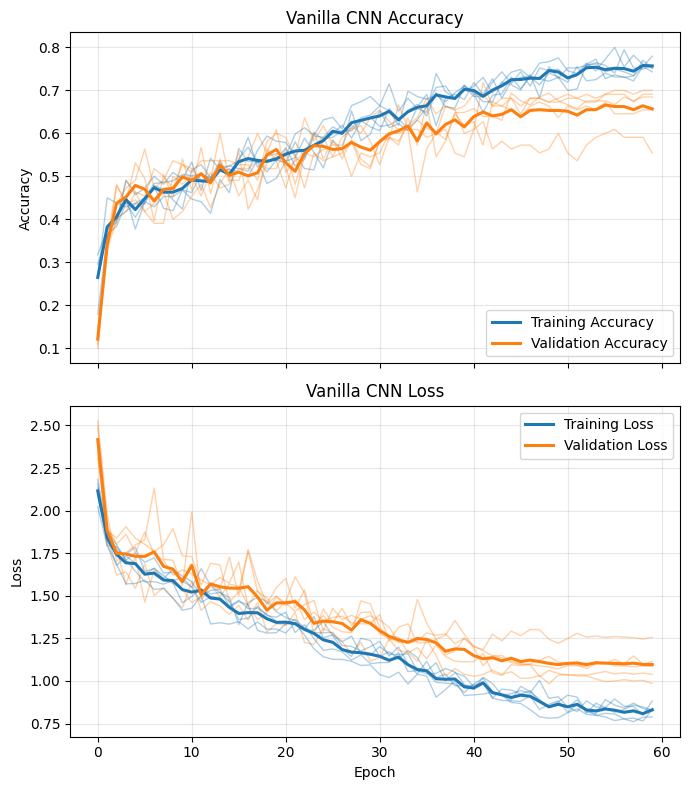

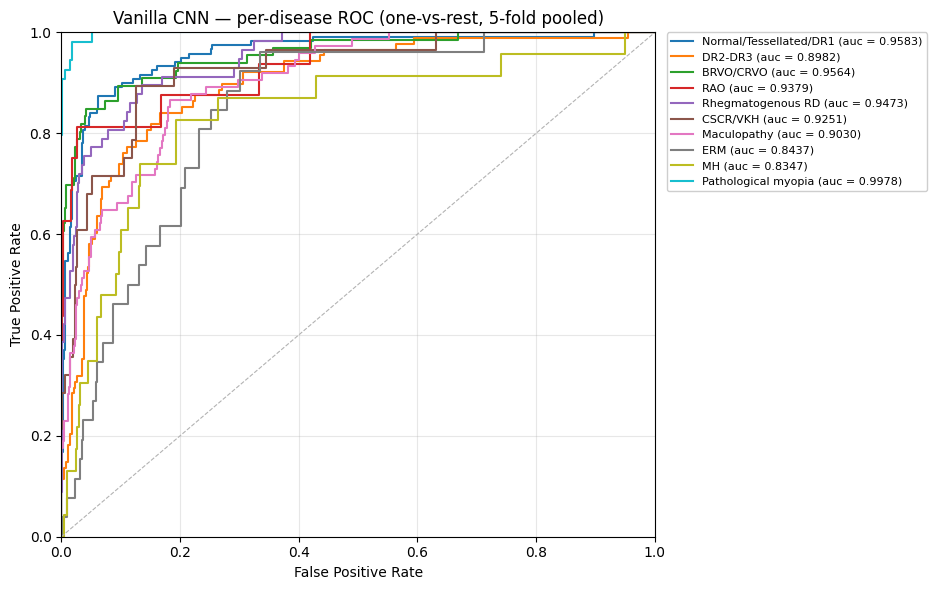


per-class AUC (one-vs-rest, pooled across folds):
  Pathological myopia            0.9978
  Normal/Tessellated/DR1         0.9583
  BRVO/CRVO                      0.9564
  Rhegmatogenous RD              0.9473
  RAO                            0.9379
  CSCR/VKH                       0.9251
  Maculopathy                    0.9030
  DR2-DR3                        0.8982
  ERM                            0.8437
  MH                             0.8347


In [5]:
import os, sys, glob, importlib, json, numpy as np, matplotlib.pyplot as plt

# auto-locate fundus_lib (same trick as cell 1) and force a reload so any
# updates pushed to drive after the kernel started are actually picked up
hits = glob.glob("/content/drive/MyDrive/**/fundus_lib/__init__.py", recursive=True)
assert hits, "fundus_lib not found anywhere under MyDrive — check the upload"
PROJECT_DIR = os.path.dirname(os.path.dirname(hits[0]))
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

# drop any cached fundus_lib.* modules and re-import fresh from disk
for mod in [m for m in list(sys.modules) if m == "fundus_lib" or m.startswith("fundus_lib.")]:
    del sys.modules[mod]
import fundus_lib as fl
import fundus_lib.metrics  # noqa: ensures submodule is in sys.modules
print("fl.metrics ->", fl.metrics.__file__)
print("has plot_history?", hasattr(fl.metrics, "plot_history"))
print("has plot_roc_per_class?", hasattr(fl.metrics, "plot_roc_per_class"))

# --- training curves ---------------------------------------------------------
hist_path = os.path.join(RESULTS_DIR, "history_%s.json" % MODEL_NAME)
if os.path.exists(hist_path):
    histories = json.load(open(hist_path))
    fig1 = fl.metrics.plot_history(
        histories, model_name="Vanilla CNN",
        save_path=os.path.join(RESULTS_DIR, "history_%s.png" % MODEL_NAME),
    )
    plt.show()
else:
    print("no saved history found — re-run the 5-fold cell so train/val loss and accuracy are recorded")

# --- per-disease ROC (Fig 2a-style) ------------------------------------------
preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = {k: fl.metrics.bigclass_short[k] for k in range(NUM_CLASSES)}
fig2 = fl.metrics.plot_roc_per_class(
    y_true_all, y_prob_all, index_to_class=short,
    title="Vanilla CNN — per-disease ROC (one-vs-rest, 5-fold pooled)",
    save_path=os.path.join(RESULTS_DIR, "roc_per_class_%s.png" % MODEL_NAME),
)
plt.show()

# numerical per-class AUC (sorted)
per_class = fl.metrics.compute_metrics(y_true_all, y_prob_all, index_to_class=short)["per_class_auc"]
print("\nper-class AUC (one-vs-rest, pooled across folds):")
for name, auc in sorted(per_class.items(), key=lambda kv: -kv[1] if not np.isnan(kv[1]) else 0):
    print(f"  {name:30s} {auc:.4f}")

## Grad-CAM: where is the CNN looking?

Grad-CAM (Selvaraju et al., ICCV 2017) maps the model's class-specific attention back onto the input image — useful for sanity-checking whether the network is using clinically meaningful regions (optic disc, macula, lesions) or shortcut artifacts.

We target the **last conv block** of the vanilla CNN (`model.features[-1]`, output 14×14×256). For each bigclass that has at least one correctly predicted image in the last fold's test set, we pick the **highest-confidence correct** prediction and show original / heatmap / overlay. Uses the in-memory model from the 5-fold loop above, or falls back to the weights saved by the previous cell if you restarted the kernel.



In [6]:
import os, json, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# --- resolve a trained model: prefer in-memory (cell 5 last fold), else load
#     the saved weights from cell 7. that way grad-cam works in a fresh kernel
#     too, as long as the .pth file is on drive.
ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES).to(device)
if "model" in globals() and isinstance(model, torch.nn.Module):
    gradcam_model.load_state_dict(model.state_dict())
    print("using in-memory last-fold model")
elif os.path.exists(ckpt_path):
    gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print("loaded weights from", ckpt_path)
else:
    raise RuntimeError(
        "no trained model available — re-run cell 5 (5-fold loop) and cell 7 (save) first"
    )
gradcam_model.eval()

# vanilla cnn target layer = last conv block (Conv-BN-ReLU-Conv-BN-ReLU-MaxPool)
# pytorch-grad-cam hooks the block's *output* (post-pool), which is the
# spatially coarsest, most semantic feature map -- 14x14x256 for 224x224 input.
target_layers = [gradcam_model.features[-1]]

# --- pick the highest-confidence correct example per bigclass from the LAST
#     fold's test set. one fold is enough to make the figure -- the picture is
#     about *attention*, not about pooled metrics.
last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1)
y_conf = yp.max(1)

short = fl.metrics.bigclass_short
selected = []
for k in range(NUM_CLASSES):
    mask = (yt == k) & (y_pred == k)
    if not mask.any():
        continue
    cand = np.where(mask)[0]
    pick = cand[int(np.argmax(y_conf[cand]))]
    selected.append((int(pick), int(k)))
print(f"showing {len(selected)} bigclasses (correctly predicted in fold {last_test_fold})")

def _prepare(local_i):
    # raw 0-1 rgb image for display (resize matches the model's 224 input)
    row = ds_te.rows[local_i]
    raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
    rgb = np.asarray(raw, dtype=np.float32) / 255.0
    input_tensor, _ = ds_te[local_i]   # already normalized
    return input_tensor, rgb

cam = GradCAM(model=gradcam_model, target_layers=target_layers)

n = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(11, 3.2 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for r, (li, k) in enumerate(selected):
    input_tensor, rgb = _prepare(li)
    targets = [ClassifierOutputTarget(int(y_pred[li]))]
    heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
    overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)

    axes[r, 0].imshow(rgb);                axes[r, 0].axis("off")
    axes[r, 0].set_title(f"original — {short[k]}", fontsize=9, fontweight="bold")
    axes[r, 1].imshow(heatmap, cmap="jet"); axes[r, 1].axis("off")
    axes[r, 1].set_title(f"Grad-CAM (pred={short[int(y_pred[li])]}, p={y_conf[li]:.2f})", fontsize=9)
    axes[r, 2].imshow(overlay);             axes[r, 2].axis("off")
    axes[r, 2].set_title("overlay", fontsize=9)

plt.suptitle(f"Vanilla CNN — Grad-CAM on fold {last_test_fold} test set (best correct per bigclass)",
             fontsize=11, fontweight="bold", y=1.0)
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, "gradcam_%s.png" % MODEL_NAME)
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("saved", save_path)


Output hidden; open in https://colab.research.google.com to view.

## Class balance + per-fold counts

Per-class AUC depends heavily on how many positives a class actually has — a class with 18 images can hit 0.69 AUC just from sampling noise. This table puts the AUC figures from the previous cell into context.


In [7]:
import numpy as np
from collections import Counter

short = fl.metrics.bigclass_short
bc_of_idx = np.array([m["bigclass"] for m in manifest])

total = Counter(bc_of_idx.tolist())
per_fold = {f: Counter(bc_of_idx[folds == f].tolist()) for f in range(splits["n_splits"])}

# header
hdr = f'{"bigclass":<26s}{"total":>7s}' + "".join(f'{"fold"+str(f):>7s}' for f in range(splits["n_splits"]))
print(hdr)
print("-" * len(hdr))
for k in range(NUM_CLASSES):
    bc = i2c[k]
    row = f'{short[k]:<26s}{total.get(bc,0):>7d}'
    row += "".join(f'{per_fold[f].get(bc,0):>7d}' for f in range(splits["n_splits"]))
    print(row)
print("-" * len(hdr))
tot_row = f'{"TOTAL":<26s}{sum(total.values()):>7d}'
tot_row += "".join(f'{sum(per_fold[f].values()):>7d}' for f in range(splits["n_splits"]))
print(tot_row)


bigclass                    total  fold0  fold1  fold2  fold3  fold4
--------------------------------------------------------------------
Normal/Tessellated/DR1        119     24     24     24     24     23
DR2-DR3                        88     18     18     17     17     18
BRVO/CRVO                      66     13     13     14     13     13
RAO                            16      3      3      3      4      3
Rhegmatogenous RD              57     12     11     11     11     12
CSCR/VKH                       28      5      6      6      6      5
Maculopathy                    74     15     15     15     14     15
ERM                            26      5      5      5      6      5
MH                             23      5      5      4      4      5
Pathological myopia            54     11     10     11     11     11
--------------------------------------------------------------------
TOTAL                         551    111    110    110    110    110


## Confusion matrix (pooled OOF predictions)

Per-class AUC tells you *which* classes are hard; the confusion matrix tells you *what they get confused with*. Cells are row-normalized (each row sums to 1 = sensitivity for that true class); raw counts in parentheses.


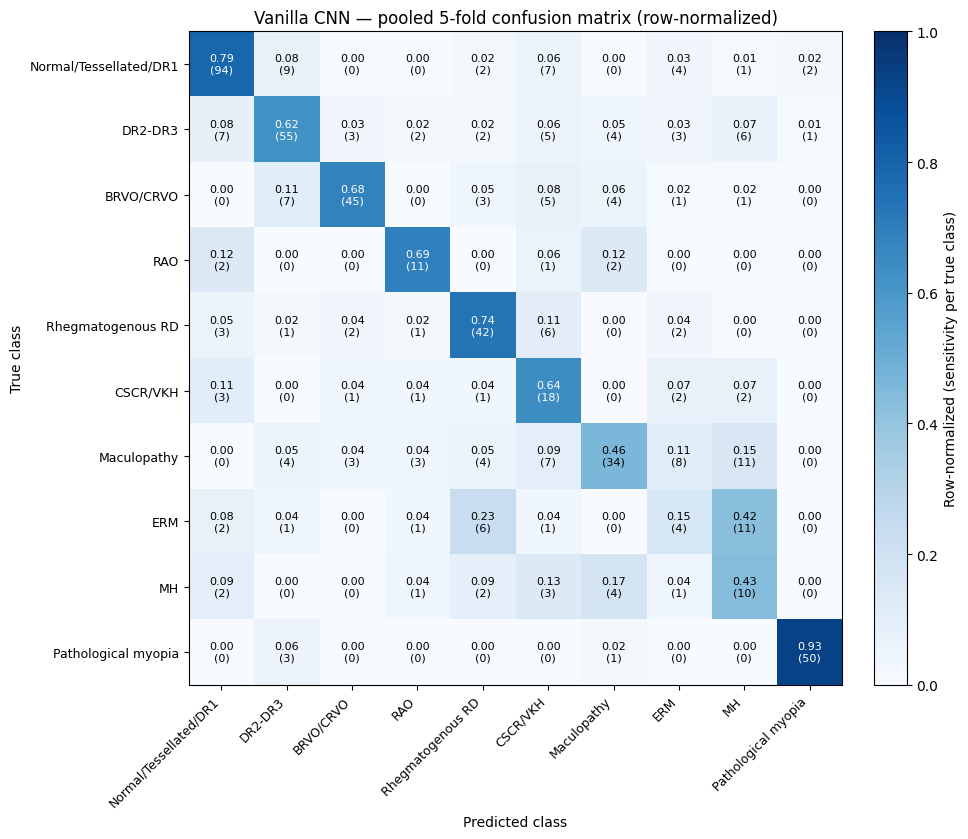

In [8]:
import os, numpy as np, matplotlib.pyplot as plt

preds = np.load(os.path.join(RESULTS_DIR, "preds_%s.npz" % MODEL_NAME))
y_true_all, y_prob_all = preds["y_true"], preds["y_prob"]
short = fl.metrics.bigclass_short

fig = fl.metrics.plot_confusion_matrix(
    y_true_all, y_prob_all, index_to_class=short,
    normalize="true",
    title="Vanilla CNN — pooled 5-fold confusion matrix (row-normalized)",
    save_path=os.path.join(RESULTS_DIR, "confusion_%s.png" % MODEL_NAME),
)
plt.show()


## Grad-CAM on failure cases

Successes only is a selection-biased view — the model can be right for the wrong reasons. We pick the **highest-confidence wrong** predictions in the last fold's test set and run Grad-CAM with **target = predicted class** (i.e. what the model thought it was seeing). The shortcut-learning literature (DeGrave et al., *Nat Mach Intell* 2021) caught most COVID-X-ray classifiers this way.


showing top 6 highest-confidence wrong predictions (of 32 failures)


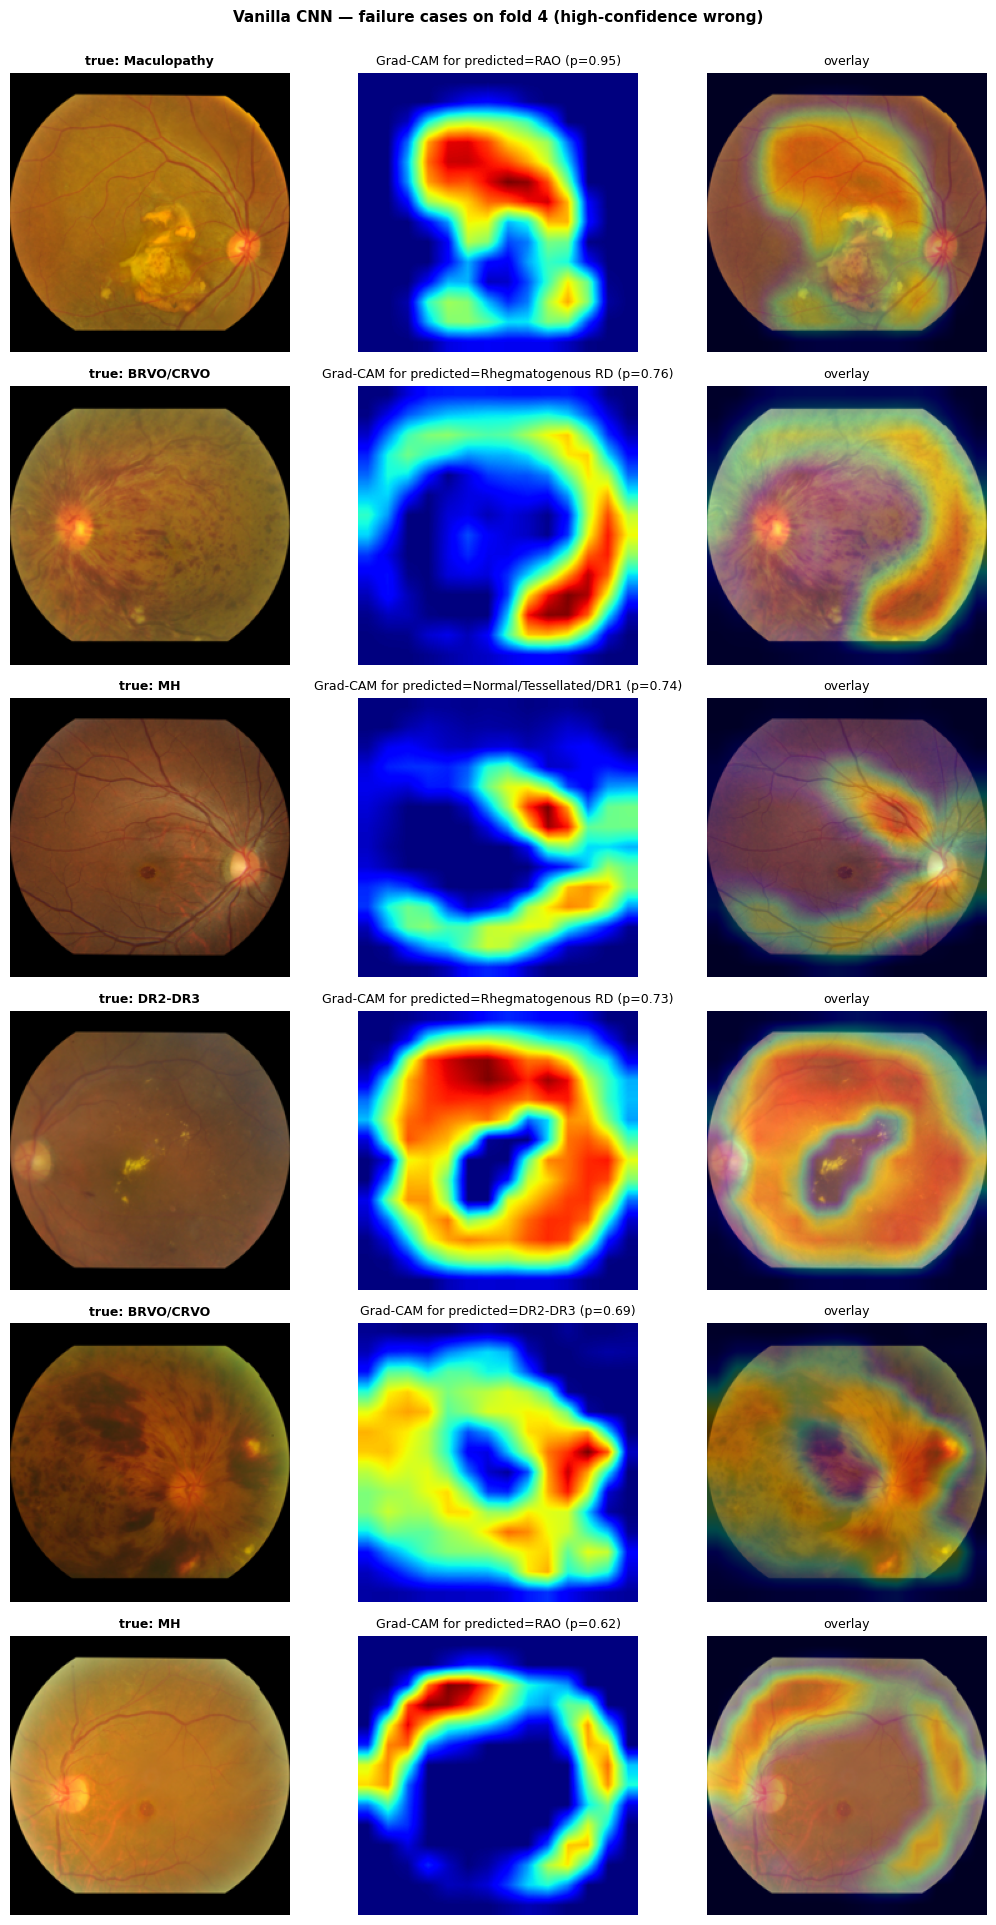

saved /content/drive/MyDrive/Drexel Biomedical AI/bmest580_group_project/bmest580_group_project/results/gradcam_failures_cnn.png


In [9]:
import os, numpy as np, matplotlib.pyplot as plt, torch
from PIL import Image
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# reuse the grad-cam model resolved in the success-case cell. fall back to disk
# if the kernel was restarted.
if "gradcam_model" not in globals():
    ckpt_path = os.path.join(RESULTS_DIR, "weights_%s_last_fold.pth" % MODEL_NAME)
    gradcam_model = fl.models.build_model(MODEL_NAME, NUM_CLASSES).to(device)
    if "model" in globals() and isinstance(model, torch.nn.Module):
        gradcam_model.load_state_dict(model.state_dict())
    elif os.path.exists(ckpt_path):
        gradcam_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    else:
        raise RuntimeError("no trained model available")
    gradcam_model.eval()

target_layers = [gradcam_model.features[-1]]

# re-evaluate on the last fold (cheap) so we can pick failures
last_test_fold = splits["n_splits"] - 1
_, _, te_idx_last = fl.data.fold_indices(folds, last_test_fold)
ds_te = fl.data.FundusDataset(manifest, te_idx_last, eval_tf, c2i)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2)
yt, yp = fl.engine.evaluate(gradcam_model, dl_te, device)
y_pred = yp.argmax(1)
y_conf = yp.max(1)
short = fl.metrics.bigclass_short

wrong = np.where(y_pred != yt)[0]
if len(wrong) == 0:
    print("no failures on the last fold")
else:
    # rank failures by predicted-class confidence (most "interesting" errors)
    order = wrong[np.argsort(-y_conf[wrong])]
    n_show = min(6, len(order))
    picks = order[:n_show]
    print(f"showing top {n_show} highest-confidence wrong predictions (of {len(wrong)} failures)")

    def _prepare(local_i):
        row = ds_te.rows[local_i]
        raw = Image.open(row.get("cache_path", row["path"])).convert("RGB").resize((224, 224))
        rgb = np.asarray(raw, dtype=np.float32) / 255.0
        input_tensor, _ = ds_te[local_i]
        return input_tensor, rgb

    cam = GradCAM(model=gradcam_model, target_layers=target_layers)
    fig, axes = plt.subplots(n_show, 3, figsize=(11, 3.2 * n_show))
    if n_show == 1:
        axes = axes.reshape(1, -1)

    for r, li in enumerate(picks):
        input_tensor, rgb = _prepare(int(li))
        # target = what the model *thought* the class was -- shows what convinced it
        targets = [ClassifierOutputTarget(int(y_pred[li]))]
        heatmap = cam(input_tensor=input_tensor.unsqueeze(0).to(device), targets=targets)[0]
        overlay = show_cam_on_image(rgb, heatmap, use_rgb=True, image_weight=0.75)

        true_name = short[int(yt[li])]
        pred_name = short[int(y_pred[li])]
        axes[r, 0].imshow(rgb); axes[r, 0].axis("off")
        axes[r, 0].set_title(f"true: {true_name}", fontsize=9, fontweight="bold")
        axes[r, 1].imshow(heatmap, cmap="jet"); axes[r, 1].axis("off")
        axes[r, 1].set_title(f"Grad-CAM for predicted={pred_name} (p={y_conf[li]:.2f})", fontsize=9)
        axes[r, 2].imshow(overlay); axes[r, 2].axis("off")
        axes[r, 2].set_title("overlay", fontsize=9)

    plt.suptitle(f"Vanilla CNN — failure cases on fold {last_test_fold} (high-confidence wrong)",
                 fontsize=11, fontweight="bold", y=1.0)
    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, "gradcam_failures_%s.png" % MODEL_NAME)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("saved", save_path)
